# Intro

## Import

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from PIL import Image
from collections import Counter

In [2]:
dataset_path = "../dataset"

sizes = []

for label in ["yes", "no"]:
  folder = os.path.join(dataset_path, label)

  for file in os.listdir(folder):
    filepath = os.path.join(folder, file)

    try:
      with Image.open(filepath) as img:
        sizes.append(img.size)

    except Exception as e:
      print("Skipped:", file, "| Error:", e)

print("Total Images:", len(sizes))

size_counts = Counter(sizes)

for size, count in size_counts.most_common():
  print(f"{size} : {count}")

Total Images: 253
(225, 225) : 18
(630, 630) : 10
(201, 251) : 5
(512, 512) : 4
(300, 325) : 4
(442, 442) : 4
(310, 380) : 3
(911, 938) : 3
(300, 168) : 3
(232, 217) : 3
(319, 360) : 2
(1059, 1200) : 2
(254, 325) : 2
(289, 300) : 2
(400, 431) : 2
(272, 350) : 2
(206, 244) : 2
(314, 340) : 2
(240, 300) : 2
(1024, 1024) : 2
(504, 630) : 2
(250, 294) : 2
(450, 446) : 2
(620, 620) : 2
(173, 201) : 2
(218, 231) : 2
(228, 221) : 2
(208, 242) : 2
(200, 252) : 2
(201, 250) : 2
(220, 275) : 2
(393, 400) : 2
(180, 218) : 1
(287, 348) : 1
(300, 336) : 1
(587, 630) : 1
(825, 993) : 1
(700, 890) : 1
(205, 246) : 1
(200, 253) : 1
(258, 279) : 1
(400, 369) : 1
(272, 324) : 1
(310, 366) : 1
(254, 312) : 1
(178, 249) : 1
(260, 298) : 1
(249, 269) : 1
(246, 310) : 1
(377, 500) : 1
(224, 245) : 1
(311, 355) : 1
(321, 352) : 1
(231, 283) : 1
(300, 359) : 1
(310, 355) : 1
(286, 370) : 1
(232, 309) : 1
(283, 334) : 1
(303, 354) : 1
(313, 360) : 1
(297, 348) : 1
(273, 351) : 1
(270, 316) : 1
(264, 336) : 1
(

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  "../dataset",
  validation_split=0.2,
  subset="training",
  seed=SEED,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  "../dataset",
  validation_split=0.2,
  subset="validation",
  seed=SEED,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  color_mode="grayscale"
)

Found 253 files belonging to 2 classes.


Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [5]:
class_names = train_ds.class_names
print(class_names)

['no', 'yes']


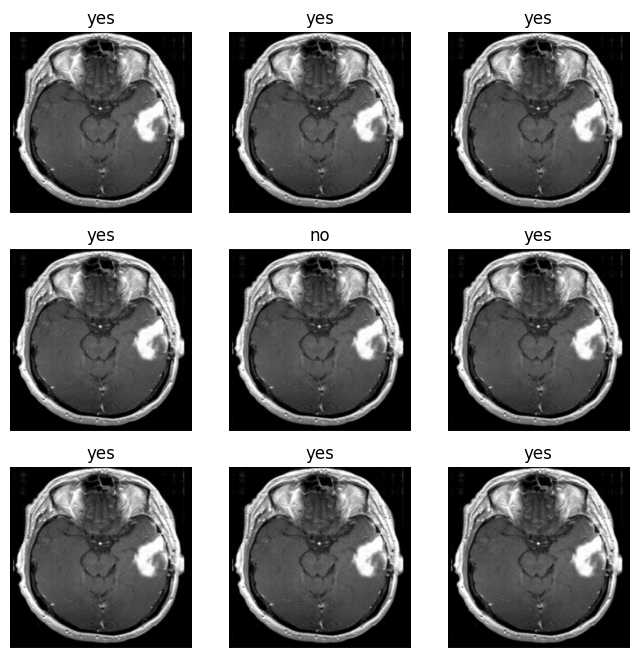

In [6]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[1].numpy().squeeze(), cmap="gray")
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(224, 224, 1)),

  tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
  tf.keras.layers.MaxPooling2D((2, 2)),

  tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
  tf.keras.layers.MaxPooling2D((2, 2)),

  tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
  tf.keras.layers.MaxPooling2D((2, 2)),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dropout(0.4),

  tf.keras.layers.Dense(1, activation="sigmoid")
])

In [10]:
model.compile(
  optimizer="adam",
  loss="binary_crossentropy",
  metrics=["accuracy"]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,937,985 (49.35 MB)

 Trainable params: 12,937,985 (49.35 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.6650 - loss: 0.6683 - val_accuracy: 0.7000 - val_loss: 0.5786
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7882 - loss: 0.4586 - val_accuracy: 0.7800 - val_loss: 0.5775
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8030 - loss: 0.4046 - val_accuracy: 0.8600 - val_loss: 0.5671
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8916 - loss: 0.3114 - val_accuracy: 0.8000 - val_loss: 0.5178
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9163 - loss: 0.2321 - val_accuracy: 0.8400 - val_loss: 0.5928
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9557 - loss: 0.1421 - val_accuracy: 0.8200 - val_loss: 0.6136
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9557 - loss: 0.1184 - val_accuracy: 0.8200 - val_loss: 0.5044
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9655 - loss: 0.0939 - val_accuracy: 0.8200 - v

In [13]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

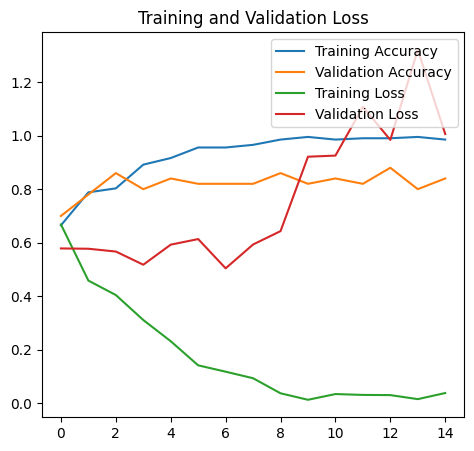

In [14]:
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

plt.show()

In [15]:
val_loss, val_acc = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8400 - loss: 1.0059
Validation Loss: 1.0059258937835693
Validation Accuracy: 0.8399999737739563


In [16]:
y_true = []
y_pred = []

for images, labels, in val_ds:
  predictions = model.predict(images)
  predicted_labels = (predictions > 0.5).astype(int).flatten()

  y_true.extend(labels.numpy().astype(int).flatten())
  y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


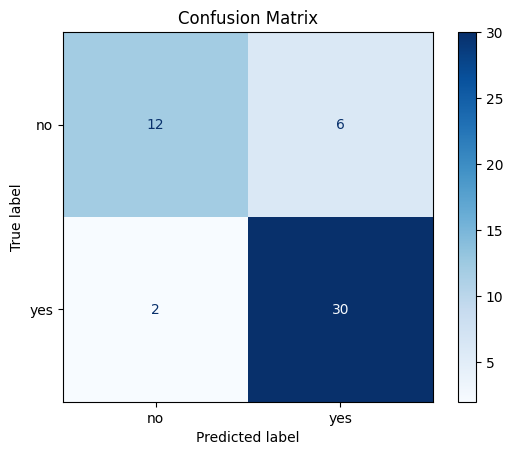

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

          no       0.86      0.67      0.75        18
         yes       0.83      0.94      0.88        32

    accuracy                           0.84        50
   macro avg       0.85      0.80      0.82        50
weighted avg       0.84      0.84      0.83        50



In [19]:
model.save("../results/tumor_classfier.h5")

In [20]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []
misclassified_scores = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0).flatten()
    predicted_labels = (predictions > 0.5).astype(int)
    true_labels = labels.numpy().astype(int).flatten()

    for i in range(len(images)):
        if predicted_labels[i] != true_labels[i]:
            misclassified_images.append(images[i].numpy())
            misclassified_true.append(true_labels[i])
            misclassified_pred.append(predicted_labels[i])
            misclassified_scores.append(predictions[i])

print("Total misclassified images:", len(misclassified_images))

Total misclassified images: 8


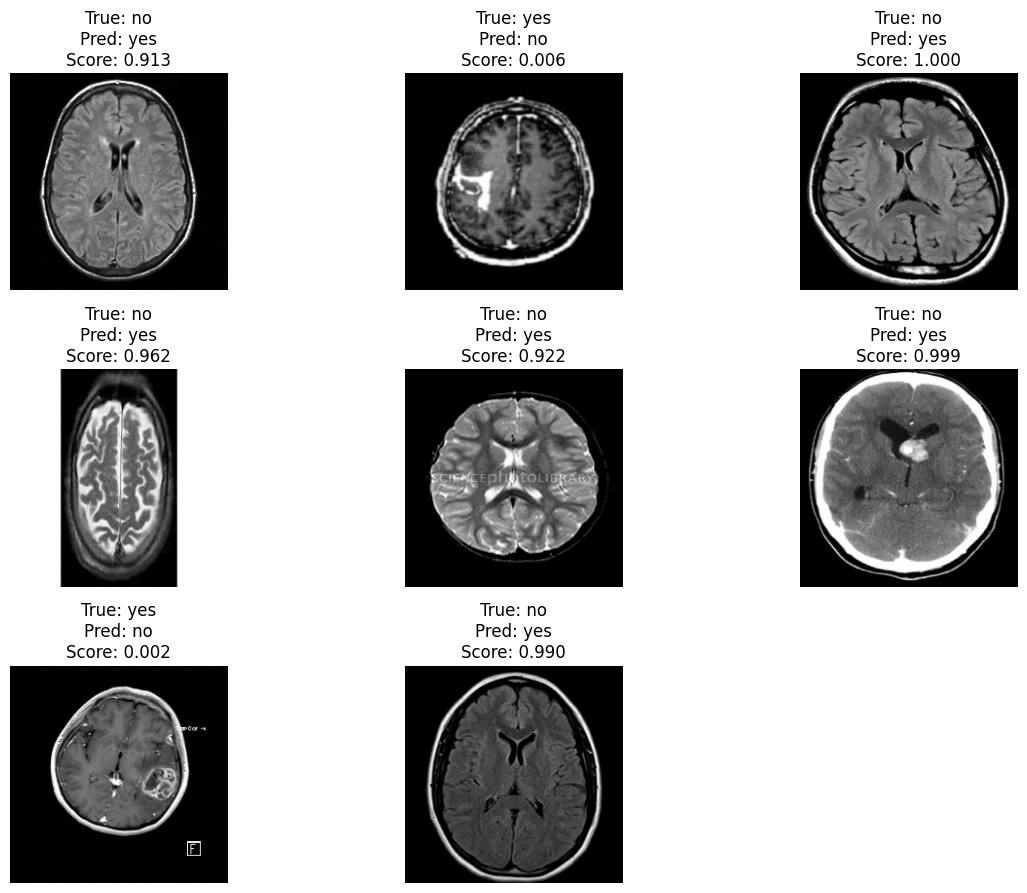

In [21]:
num_to_show = min(12, len(misclassified_images))

plt.figure(figsize=(12, 12))

for i in range(num_to_show):
    ax = plt.subplot(4, 3, i + 1)
    plt.imshow(misclassified_images[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[misclassified_true[i]]}\n"
        f"Pred: {class_names[misclassified_pred[i]]}\n"
        f"Score: {misclassified_scores[i]:.3f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()